In [1]:
import pandas as pd
import numpy as np

# Loan Default Prediction



## Data Loading


In [2]:
df_train = pd.read_csv("../data/raw/cs-training.csv")
df_test = pd.read_csv("../data/raw/cs-test.csv")

## Data Cleaning

In [3]:
df_train.head()
df_train.shape
df_train.info()
df_train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [4]:
df_train.drop(columns=["Unnamed: 0"], inplace=True)
df_test.drop(columns=["Unnamed: 0"], inplace=True)

In [5]:
df_train.isnull().sum().sort_values(ascending=False)

MonthlyIncome                           29731
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
age                                         0
RevolvingUtilizationOfUnsecuredLines        0
DebtRatio                                   0
NumberOfTime30-59DaysPastDueNotWorse        0
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
dtype: int64

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
median_income = df_train["MonthlyIncome"].median()

df_train["MonthlyIncome"] = df_train["MonthlyIncome"].fillna(median_income)
df_test["MonthlyIncome"] = df_test["MonthlyIncome"].fillna(median_income)

In [10]:
median_dependents = df_train["NumberOfDependents"].median()

df_train["NumberOfDependents"] = df_train["NumberOfDependents"].fillna(median_dependents)
df_test["NumberOfDependents"] = df_test["NumberOfDependents"].fillna(median_dependents)

In [11]:
df_train["age"].value_counts()

age
49     3837
48     3806
50     3753
47     3719
63     3719
       ... 
102       3
109       2
107       1
105       1
0         1
Name: count, Length: 86, dtype: int64

In [13]:
df_train = df_train[df_train["age"]>0]
df_test["age"] = df_test["age"].clip(lower=1)

## Feature Engineering

In [15]:
df_train["AnyPastDue"] = (
    (df_train["NumberOfTime60-89DaysPastDueNotWorse"] > 0) |
    (df_train["NumberOfTime30-59DaysPastDueNotWorse"] > 0) |
    (df_train["NumberOfTimes90DaysLate"] > 0)
).astype(int)
df_test["AnyPastDue"] = (
    (df_test["NumberOfTime60-89DaysPastDueNotWorse"] > 0) |
    (df_test["NumberOfTime30-59DaysPastDueNotWorse"] > 0) |
    (df_test["NumberOfTimes90DaysLate"] > 0)
).astype(int)

In [17]:
df_train["TotalNumberOfTimePastDue"] = (
    df_train["NumberOfTime60-89DaysPastDueNotWorse"] +
    df_train["NumberOfTime30-59DaysPastDueNotWorse"] +
    df_train["NumberOfTimes90DaysLate"]
)
df_test["TotalNumberOfTimePastDue"] = (
    df_test["NumberOfTime60-89DaysPastDueNotWorse"] +
    df_test["NumberOfTime30-59DaysPastDueNotWorse"] +
    df_test["NumberOfTimes90DaysLate"]
)

In [18]:
df_train["DebtToIncome"] = df_train["DebtRatio"] / (df_train["MonthlyIncome"] + 1)
df_test["DebtToIncome"] = df_test["DebtRatio"] / (df_test["MonthlyIncome"] + 1)

In [20]:
df_train.to_csv("../data/processed/train_clean.csv")
df_test.to_csv("../data/processed/test_clean.csv")

## Model - Logistic Regression

In [25]:
X = df_train.drop("SeriousDlqin2yrs", axis=1)
y = df_train["SeriousDlqin2yrs"]
X_test = df_test.drop("SeriousDlqin2yrs", axis=1)
y_test = df_test["SeriousDlqin2yrs"]

In [59]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
test_preds = np.zeros(len(X_test))
precision_scores = []
recall_scores = []

for train_idx, val_idx in kf.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="saga"
    )

    model.fit(X_train_scaled, y_train)

    val_probs = model.predict_proba(X_val_scaled)[:, 1]
    auc = roc_auc_score(y_val, val_probs)
    cv_scores.append(auc)
    preds = (val_probs >= 0.5).astype(int)
    precision_scores.append(precision_score(y_val, preds))
    recall_scores.append(recall_score(y_val, preds))

    test_preds += model.predict_proba(X_test_scaled)[:, 1]

test_preds /= kf.n_splits

print("Mean CV AUC:", np.mean(cv_scores))
print("Mean Precision:", np.mean(precision_scores))
print("Mean Recall:", np.mean(recall_scores))

Mean CV AUC: 0.8075499699006847
Mean Precision: 0.22283220430183626
Mean Recall: 0.673948578205533


In [60]:
submission = pd.DataFrame({
    "Id": np.arange(len(df_test)),
    "Probability": test_preds
})
submission.to_csv("../submission/logistic_submission.csv", index=False)

## Model - XGBoost

In [61]:
from xgboost import XGBClassifier

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_xgboost = []
precision_scores_xgboost = []
recall_scores_xgboost = []
test_preds_xgboost = np.zeros(len(X_test))

scale_pos_weight = (len(y[y == 0]) / len(y[y == 1]))

for train_idx, val_idx in kf.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc"
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_preds = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, val_preds)
    cv_scores_xgboost.append(auc)
    preds = (val_preds >= 0.5).astype(int)
    precision_scores_xgboost.append(precision_score(y_val, preds))
    recall_scores_xgboost.append(recall_score(y_val, preds))

    test_preds_xgboost += model.predict_proba(X_test)[:, 1]


test_preds_xgboost /= kf.n_splits

print("Mean CV AUC:", np.mean(cv_scores_xgboost))
print("Mean Precision:", np.mean(precision_scores_xgboost))
print("Mean Recall:", np.mean(recall_scores_xgboost))

Mean CV AUC: 0.8659134901191461
Mean Precision: 0.21913253157043283
Mean Recall: 0.7743874113320885


In [62]:
submission = pd.DataFrame({
    "Id": np.arange(len(df_test)),
    "Probability": test_preds_xgboost
})
submission.to_csv("../submission/XGBoost_submission.csv", index=False)

## Conclusion 
A credit risk prediction model was developed using Logistic Regression and XGBoost.

The dataset required preprocessing, including handling missing values and engineering features such as TotalNumberOfTimePastDue , AnyPastDue, and DebtToIncome.

Model performance was evaluated using 5-fold stratified cross-validation with AUC, Precision, and Recall due to class imbalance.

### Key Findings:
- XGBoost outperformed Logistic Regression in AUC and Recall.
- Logistic Regression served as a strong baseline but showed lower sensitivity to the minority class.
- Class imbalance handling using class weights and scale adjustments improved recall significantly.
- Feature engineering had a strong impact on performance.

### Final Model:
XGBoost was selected as the final model due to higher AUC and better recall for the default class.

### Key Insight:
In credit risk prediction, recall for the default class is more critical than overall accuracy, as failing to identify high-risk customers carries higher cost than false positives.

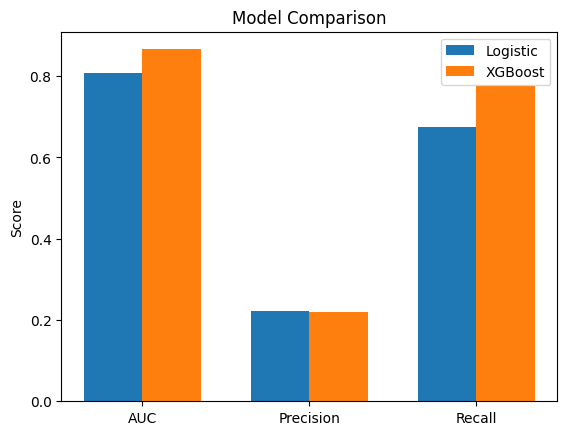

In [65]:
import matplotlib.pyplot as plt

labels = ["AUC", "Precision", "Recall"]

log_means = [
    np.mean(cv_scores),
    np.mean(precision_scores),
    np.mean(recall_scores)
]

xgb_means = [
    np.mean(cv_scores_xgboost),
    np.mean(precision_scores_xgboost),
    np.mean(recall_scores_xgboost)
]

x = np.arange(len(labels))
width = 0.35

plt.figure()

plt.bar(x - width/2, log_means, width, label="Logistic")
plt.bar(x + width/2, xgb_means, width, label="XGBoost")

plt.xticks(x, labels)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.legend()
plt.savefig("../assets/model_comparison.png")

plt.show()